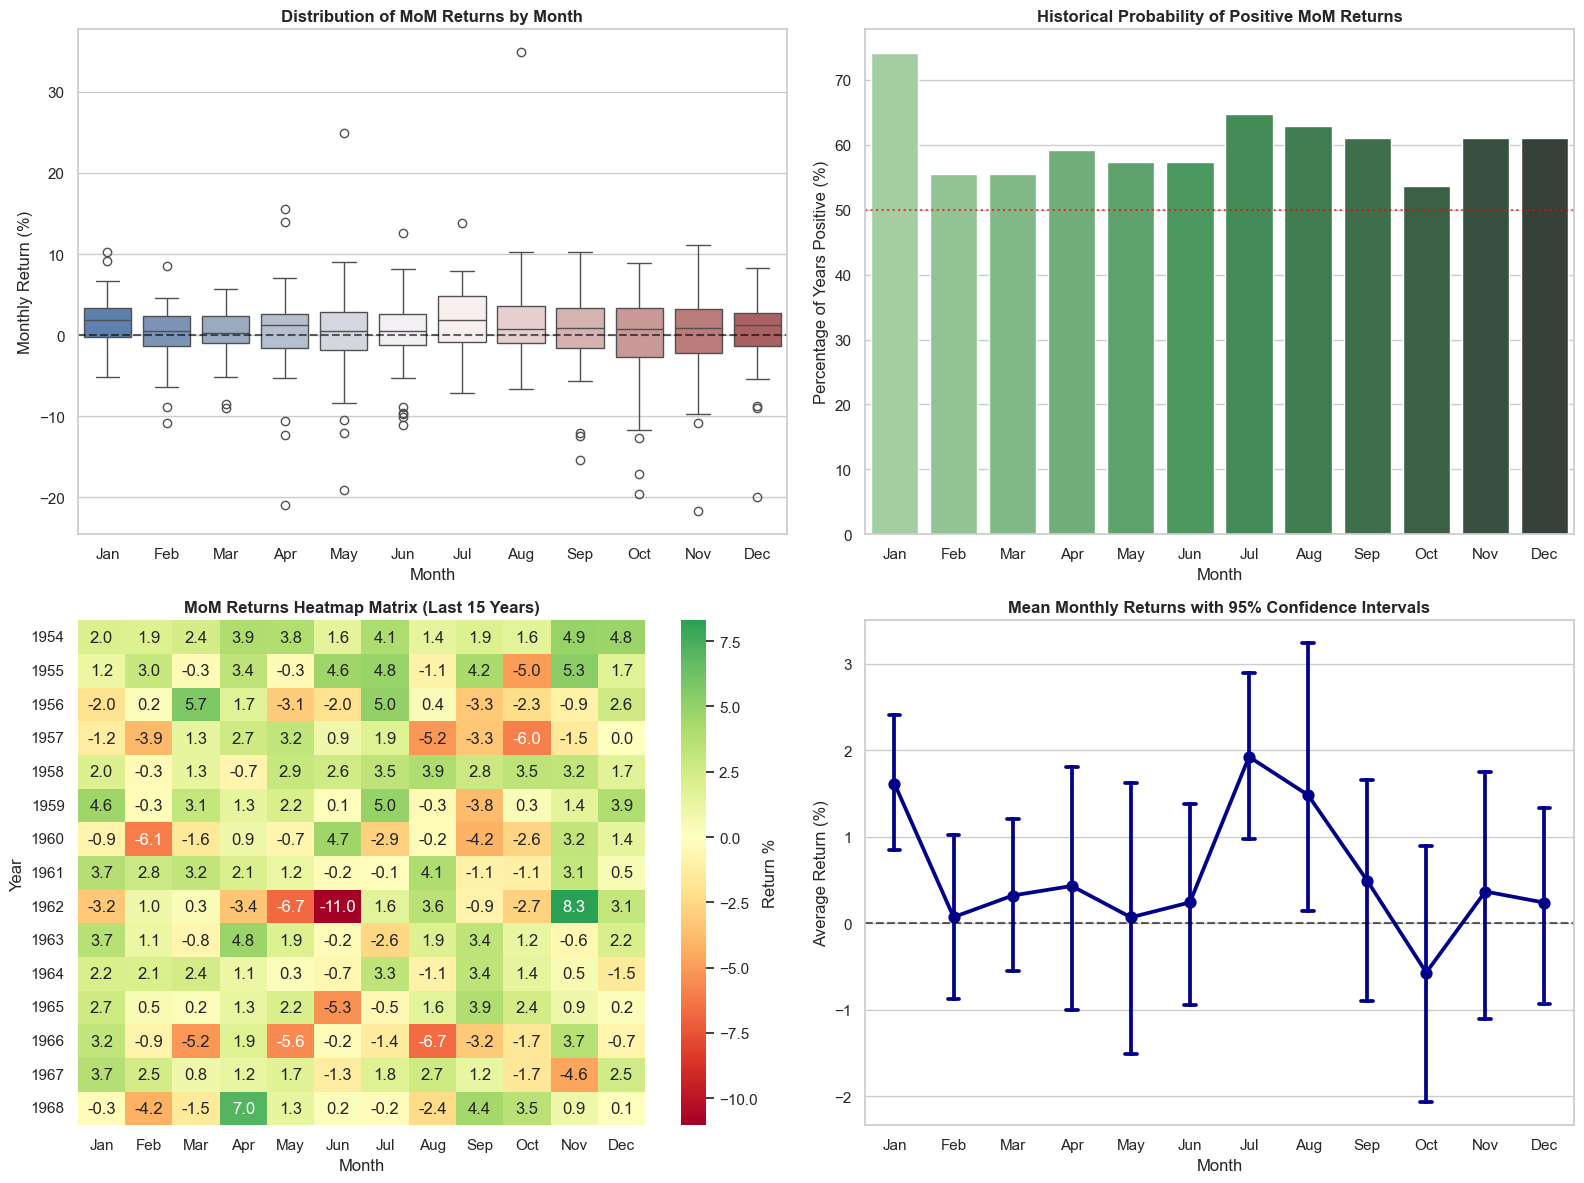

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- 1. PREPARATION & CALENDAR FEATURE EXTRACTION ---
# Load dataset directly into df
df = sns.load_dataset("dowjones")
df["Date"] = pd.to_datetime(df["Date"])

# Extract time anchors
df["Year"] = df["Date"].dt.year
df["Month_Num"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")

# Calculate Month-over-Month percentage return
df["MoM_Return"] = df["Price"].pct_change() * 100

# Drop the first row since it won't have a MoM calculation anchor
df_clean = df.dropna().copy()

# Sort month names logically for clean graph axis representations
months_order = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]
df_clean["Month_Name"] = pd.Categorical(
    df_clean["Month_Name"], categories=months_order, ordered=True
)

# Set global graph layout
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- 2. HISTORICAL PERFORMANCE BY MONTH (BOXPLOT) ---
sns.boxplot(
    ax=axes[0, 0],
    data=df_clean,
    x="Month_Name",
    y="MoM_Return",
    palette="vlag",
    hue="Month_Name",
    legend=False,
)
axes[0, 0].axhline(0, color="black", linestyle="--", alpha=0.6)
axes[0, 0].set_title(
    "Distribution of MoM Returns by Month", fontsize=12, fontweight="bold"
)
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Monthly Return (%)")

# --- 3. PROBABILITY OF A POSITIVE MONTH (BARPLOT) ---
df_clean["Is_Positive"] = df_clean["MoM_Return"] > 0
win_rate = (
    df_clean.groupby("Month_Name", observed=False)["Is_Positive"]
    .mean()
    .reset_index()
)
win_rate["Win_Rate_Pct"] = win_rate["Is_Positive"] * 100

sns.barplot(
    ax=axes[0, 1],
    data=win_rate,
    x="Month_Name",
    y="Win_Rate_Pct",
    palette="Greens_d",
    hue="Month_Name",
    legend=False,
)
axes[0, 1].axhline(50, color="red", linestyle=":", alpha=0.7)
axes[0, 1].set_title(
    "Historical Probability of Positive MoM Returns",
    fontsize=12,
    fontweight="bold",
)
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Percentage of Years Positive (%)")

# --- 4. THE MONTH-OVER-MONTH PERFORMANCE MATRIX (HEATMAP) ---
pivot_returns = df_clean.pivot(
    index="Year", columns="Month_Name", values="MoM_Return"
)

sns.heatmap(
    ax=axes[1, 0],
    data=pivot_returns.tail(15),
    cmap="RdYlGn",
    center=0,
    annot=True,
    fmt=".1f",
    cbar_kws={"label": "Return %"},
)
axes[1, 0].set_title(
    "MoM Returns Heatmap Matrix (Last 15 Years)", fontsize=12, fontweight="bold"
)
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Year")

# --- 5. AVERAGED SEASONAL TREND LINES (POINTPLOT) ---
sns.pointplot(
    ax=axes[1, 1],
    data=df_clean,
    x="Month_Name",
    y="MoM_Return",
    color="darkblue",
    errorbar="ci",
    capsize=0.2,
)
axes[1, 1].axhline(0, color="black", linestyle="--", alpha=0.6)
axes[1, 1].set_title(
    "Mean Monthly Returns with 95% Confidence Intervals",
    fontsize=12,
    fontweight="bold",
)
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Average Return (%)")

plt.tight_layout()
plt.show()


In [2]:
df

,Date,Price,Year,Month_Num,Month_Name,MoM_Return
0,1914-12-01,55.00,1914,12,Dec,NaN
1,1915-01-01,56.55,1915,1,Jan,2.818182
2,1915-02-01,56.00,1915,2,Feb,-0.972591
3,1915-03-01,58.30,1915,3,Mar,4.107143
4,1915-04-01,66.45,1915,4,Apr,13.979417
...,...,...,...,...,...,...
644,1968-08-01,883.72,1968,8,Aug,-2.385897
645,1968-09-01,922.80,1968,9,Sep,4.422215
646,1968-10-01,955.47,1968,10,Oct,3.540312
647,1968-11-01,964.12,1968,11,Nov,0.905314
